In [1]:
from a3em.datasets import arden
import os
from pathlib import Path

In [2]:
prefetch_path = Path(os.getenv('PREFETCH_PATH'))
X_train, X_test, y_train, y_test = arden.load_data(prefetch_path, random_state=123)

prefetching data...
local data found


In [3]:
X_train.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
108,23.437500,131.479134,109.114844,22.460938,124.023438,-239.949573,215.480924,12.683605,27.450771,9.969726,...,0.001534,0.000692,0.000419,0.000306,0.000179,0.000079,0.000032,0.000010,2.325721e-06,4.485630e-07
141,22.460938,113.318518,93.047050,22.460938,126.953125,-283.407941,219.353551,27.589489,26.634377,29.320037,...,0.000366,0.000182,0.000089,0.000051,0.000018,0.000008,0.000004,0.000001,4.849924e-07,1.305073e-07
19,55.664062,156.512551,134.379832,23.437500,165.039062,-294.283564,201.174292,-8.764452,23.626552,-2.545009,...,0.001232,0.000860,0.000504,0.000209,0.000108,0.000042,0.000019,0.000009,3.100925e-06,1.150773e-06
120,23.437500,106.667424,90.428045,22.460938,115.234375,-276.502642,220.106922,35.009477,27.049288,24.789322,...,0.000336,0.000187,0.000102,0.000062,0.000032,0.000014,0.000006,0.000003,1.585009e-06,1.249641e-06
48,41.015625,184.689889,142.453849,27.343750,300.781250,-190.161678,216.008476,-39.503599,38.500591,-29.422877,...,0.022118,0.011840,0.005529,0.004427,0.002883,0.000825,0.000210,0.000081,2.737891e-05,1.946964e-05


In [4]:
y_train.head()

108    3
141    3
19     0
120    4
48     0
Name: quality, dtype: int64

In [5]:
X_train.to_csv('./data/train/features.csv')
X_test.to_csv('./data/test/features.csv')
y_train.to_csv('./data/train/labels.csv')
y_test.to_csv('./data/test/labels.csv')

## Analysis

In [6]:
import pandas as pd

In [7]:
train_features = pd.read_csv('./data/train/features.csv')
train_labels = pd.read_csv('./data/train/labels.csv')

In [8]:
# create a binary classifier for rumbles
train_labels['label'] = train_labels['quality'].replace({
    0: 0,
    3: 1,
    4: 1
})
train_labels['label'].value_counts()

label
1    139
0     43
Name: count, dtype: int64

In [10]:
# Remove identifier columns
train_features = train_features.drop(columns=['Unnamed: 0'])
train_labels = train_labels.drop(columns=['Unnamed: 0', 'quality'])

# Combine
df = train_features.copy()
df['label'] = train_labels['label']

In [13]:
df.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,...,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26,label
0,23.437500,131.479134,109.114844,22.460938,124.023438,-239.949573,215.480924,12.683605,27.450771,9.969726,...,0.000692,0.000419,0.000306,0.000179,0.000079,0.000032,0.000010,2.325721e-06,4.485630e-07,1
1,22.460938,113.318518,93.047050,22.460938,126.953125,-283.407941,219.353551,27.589489,26.634377,29.320037,...,0.000182,0.000089,0.000051,0.000018,0.000008,0.000004,0.000001,4.849924e-07,1.305073e-07,1
2,55.664062,156.512551,134.379832,23.437500,165.039062,-294.283564,201.174292,-8.764452,23.626552,-2.545009,...,0.000860,0.000504,0.000209,0.000108,0.000042,0.000019,0.000009,3.100925e-06,1.150773e-06,0
3,23.437500,106.667424,90.428045,22.460938,115.234375,-276.502642,220.106922,35.009477,27.049288,24.789322,...,0.000187,0.000102,0.000062,0.000032,0.000014,0.000006,0.000003,1.585009e-06,1.249641e-06,1
4,41.015625,184.689889,142.453849,27.343750,300.781250,-190.161678,216.008476,-39.503599,38.500591,-29.422877,...,0.011840,0.005529,0.004427,0.002883,0.000825,0.000210,0.000081,2.737891e-05,1.946964e-05,0


### Compute Summary Statistics

In [21]:
summary = df.groupby("label").mean()

std_summary = df.groupby("label").std()

comparison = pd.DataFrame({
    "Background Mean": df[df["label"] == 0].mean(),
    "Rumble Mean": df[df["label"] == 1].mean(),
    "Background Std": df[df["label"] == 0].std(),
    "Rumble Std": df[df["label"] == 1].std()
})

comparison = comparison.drop(index="label")
comparison

,Background Mean,Rumble Mean,Background Std,Rumble Std
peak_freq,36.428052,24.828575,12.338917,2.999569
centroid,166.003955,118.085019,28.576500,11.085297
bandwidth,134.060997,98.704904,17.321418,9.923240
freq_5,23.028706,23.669346,4.486485,2.081860
freq_95,241.687863,120.960263,64.882332,6.491851
mfcc_1,-205.301073,-266.369633,86.027552,32.017304
mfcc_2,213.789061,217.792723,14.909209,7.550003
mfcc_3,-20.913642,24.685065,25.438478,14.336169
mfcc_4,30.595288,22.722915,8.157653,5.641850
mfcc_5,-13.867774,18.923553,12.936232,7.701888


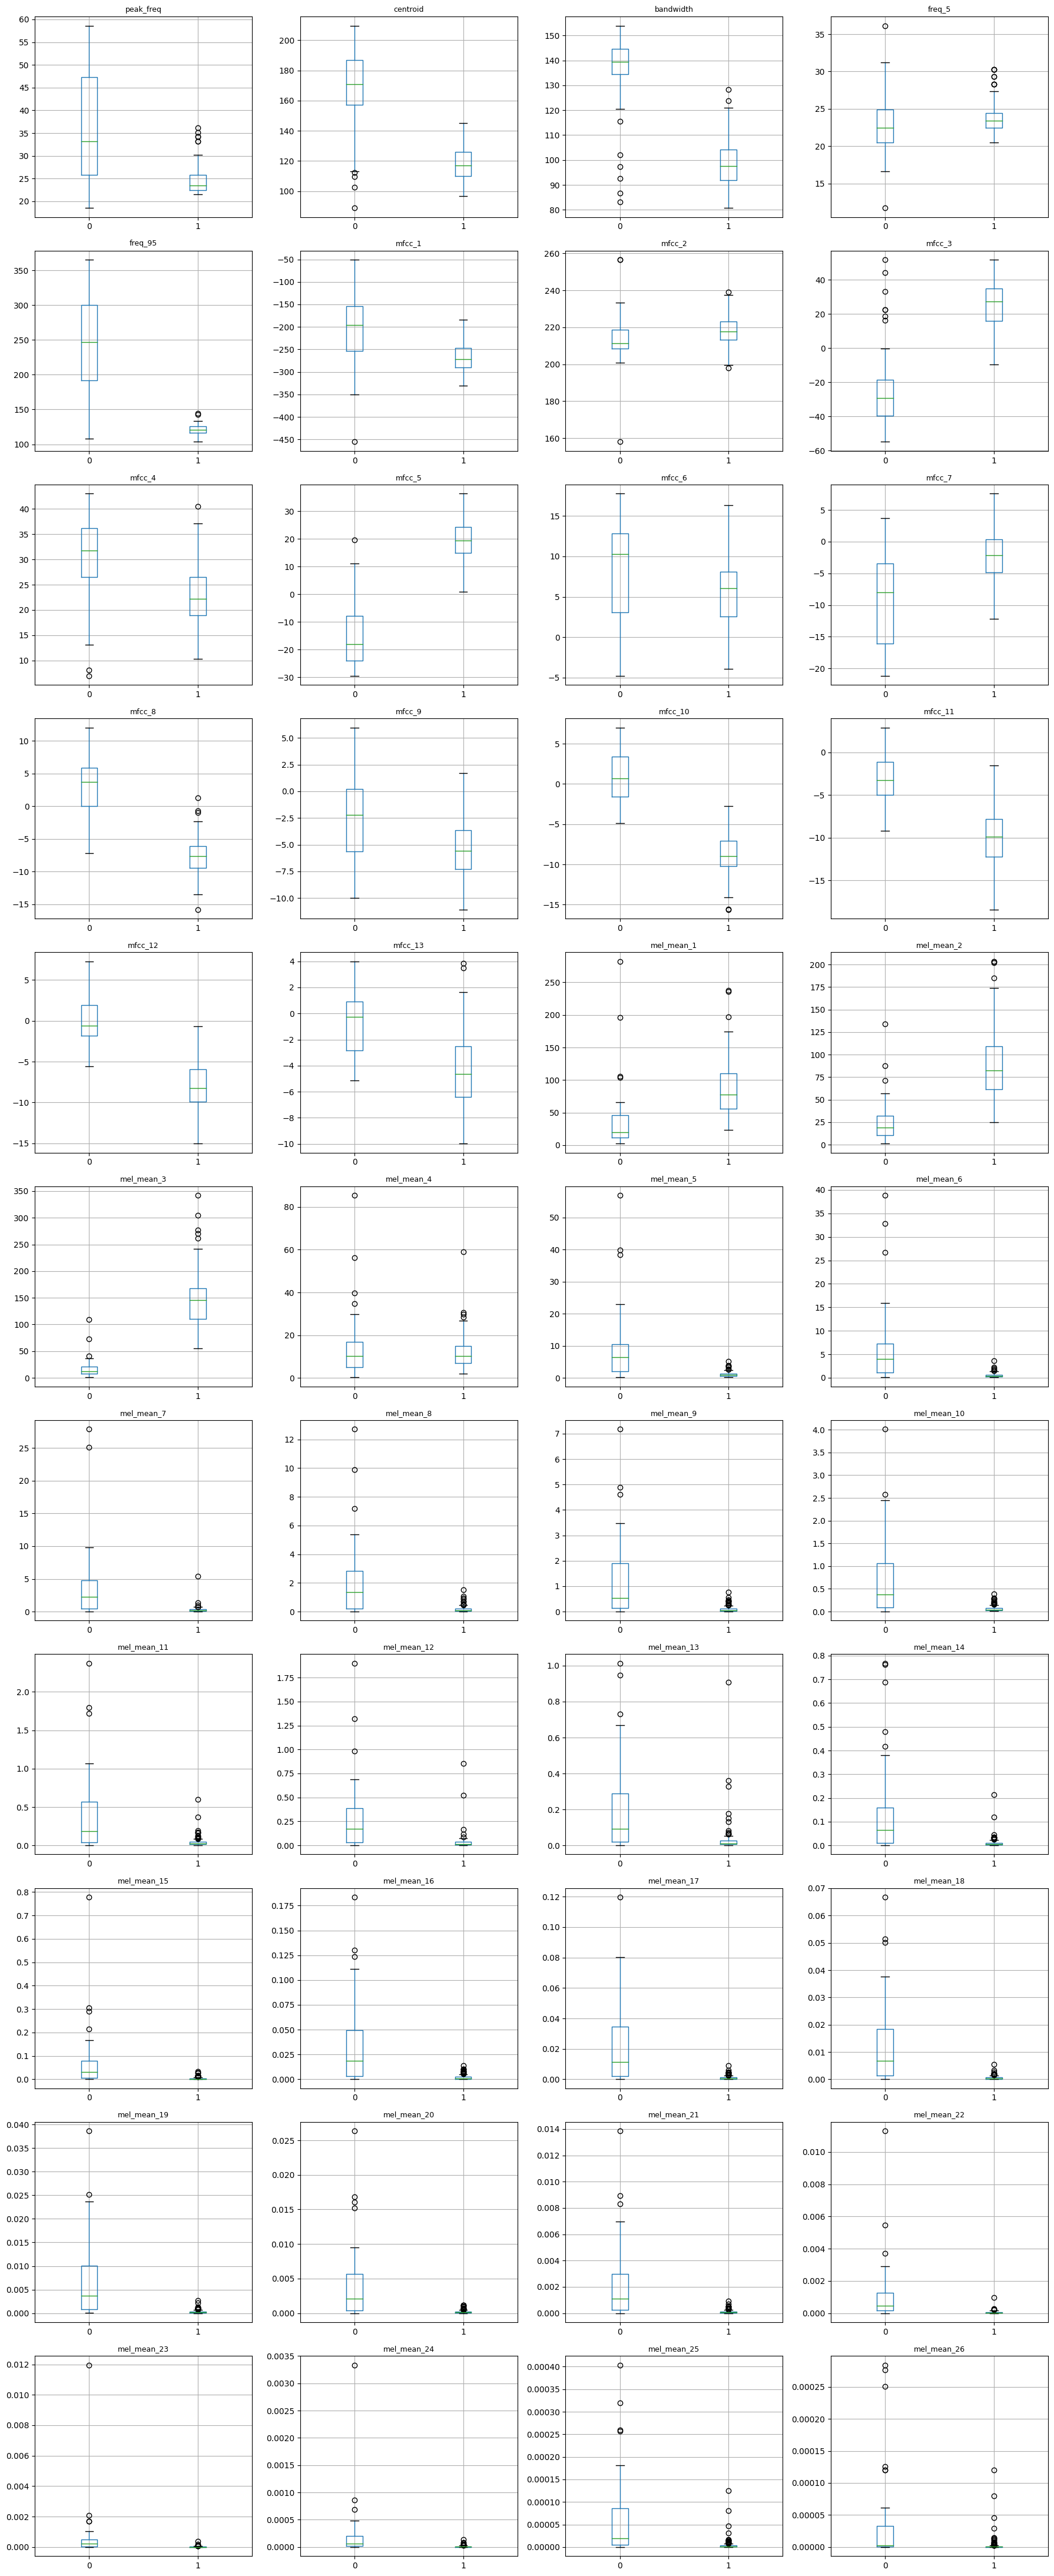

In [22]:
import matplotlib.pyplot as plt

# List of feature columns (everything except the label)
feature_cols = df.columns.drop("label")

# Determine the layout of the figure
n_features = len(feature_cols)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4 * n_rows)
)

axes = axes.flatten()

for i, feature in enumerate(feature_cols):

    df.boxplot(
        column=feature,
        by="label",
        ax=axes[i]
    )

    axes[i].set_title(feature, fontsize=9)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("")
plt.tight_layout()

plt.show()

### Statistical Testing
Because our data does not follow a uniform distribution, we will use a *** Mann-Whitney U test ***

In [23]:
from scipy.stats import mannwhitneyu

In [24]:
# run the test on every feature
results = []

feature_cols = df.columns.drop("label")

for feature in feature_cols:

    background = df[df["label"] == 0][feature]
    rumble = df[df["label"] == 1][feature]

    stat, p = mannwhitneyu(
        background,
        rumble,
        alternative="two-sided"
    )

    results.append({
        "Feature": feature,
        "U Statistic": stat,
        "P Value": p
    })

results = pd.DataFrame(results)

In [25]:
# rank the features
results = results.sort_values("P Value")

results.head(20)

,Feature,U Statistic,P Value
14,mfcc_10,5969.0,5.587823e-23
20,mel_mean_3,41.0,1.651752e-22
12,mfcc_8,5856.0,2.176305e-21
4,freq_95,5831.5,4.477267e-21
16,mfcc_12,5813.0,8.455296e-21
9,mfcc_5,172.0,1.085987e-20
15,mfcc_11,5701.0,2.638923e-19
19,mel_mean_2,390.0,7.616238e-18
2,bandwidth,5488.0,1.259791e-16
7,mfcc_3,566.0,1.038037e-15


In [ ]:
results["Significant"] = results["P Value"] < 0.05

results.head(20)

,Feature,U Statistic,P Value,Significant
14,mfcc_10,5969.0,5.587823e-23,True
20,mel_mean_3,41.0,1.651752e-22,True
12,mfcc_8,5856.0,2.176305e-21,True
4,freq_95,5831.5,4.477267e-21,True
16,mfcc_12,5813.0,8.455296e-21,True
9,mfcc_5,172.0,1.085987e-20,True
15,mfcc_11,5701.0,2.638923e-19,True
19,mel_mean_2,390.0,7.616238e-18,True
2,bandwidth,5488.0,1.259791e-16,True
7,mfcc_3,566.0,1.038037e-15,True


In [27]:
results["Significant"].value_counts()

Significant
True     42
False     2
Name: count, dtype: int64

In [28]:
results[results["Significant"] == False]

,Feature,U Statistic,P Value,Significant
3,freq_5,2544.5,0.137149,False
21,mel_mean_4,2882.0,0.725514,False


To reduce the chance of luck in our analysis, we will use a *** Benjamini–Hochberg false discovery rate (FDR) *** to adjust the p-va;ues

In [29]:
from statsmodels.stats.multitest import multipletests

results["Adjusted P"] = multipletests(
    results["P Value"],
    method="fdr_bh"
)[1]

results["Significant (FDR)"] = results["Adjusted P"] < 0.05

### Logistic Regression

In [30]:
print(X_train.shape)
print(X_test.shape)

print(y_train.value_counts())
print(y_test.value_counts())

(182, 44)
(61, 44)
quality
3    127
0     43
4     12
Name: count, dtype: int64
quality
3    41
0    16
4     4
Name: count, dtype: int64
